In [ ]:

# Install required packages
import subprocess
import sys

# Install scikit-image
result = subprocess.run([sys.executable, "-m", "pip", "install", "scikit-image"], 
                       capture_output=True, text=True)
print("scikit-image install output:")
print(result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr)

# Install other packages
packages = ['PyWavelets', 'numba', 'scipy', 'pillow']
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    print(f"Successfully installed {package}")

print("\nAll packages installed successfully")


scikit-image install output:
Defaulting to user installation because normal site-packages is not writeable




All packages installed successfully


In [ ]:

# Import required libraries - restart kernel approach
import sys
sys.path.insert(0, '/home/kerneluser/.local/lib/python3.12/site-packages')

import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from skimage.filters import sobel
from skimage.restoration import denoise_tv_chambolle
import skimage
import pywt
from numba import jit
from scipy.ndimage import uniform_filter

print(f"scikit-image version: {skimage.__version__}")
print(f"PyWavelets version: {pywt.__version__}")
print(f"NumPy version: {np.__version__}")

# Set random seeds for reproducibility
np.random.seed(42)

print("\nAll libraries imported successfully")


scikit-image version: 0.25.2
PyWavelets version: 1.8.0
NumPy version: 1.26.4

All libraries imported successfully


In [ ]:

# Define the image loading and preprocessing function
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    """
    Load an image, resize it, convert to grayscale, and normalize to [0, 1]
    """
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    img = img.resize(target_size, Image.BILINEAR)
    img_array = np.array(img, dtype=np.float64)
    img_array = img_array / 255.0  # Normalize to [0, 1]
    return img_array

# Load the 5 test images
test_images = {
    'benign_1': 'Dataset_BUSI_with_GT/benign/benign (1).png',
    'benign_198': 'Dataset_BUSI_with_GT/benign/benign (198).png',
    'malignant_1': 'Dataset_BUSI_with_GT/malignant/malignant (1).png',
    'malignant_50': 'Dataset_BUSI_with_GT/malignant/malignant (50).png',
    'malignant_146': 'Dataset_BUSI_with_GT/malignant/malignant (146).png'
}

# Load and preprocess all test images
images = {}
for name, path in test_images.items():
    if os.path.exists(path):
        images[name] = load_and_preprocess_image(path)
        print(f"Loaded {name}: shape {images[name].shape}, range [{images[name].min():.3f}, {images[name].max():.3f}]")
    else:
        print(f"Warning: {path} not found")

print(f"\nLoaded {len(images)} test images successfully")


Loaded benign_1: shape (128, 128), range [0.075, 1.000]
Loaded benign_198: shape (128, 128), range [0.016, 0.949]
Loaded malignant_1: shape (128, 128), range [0.047, 0.980]
Loaded malignant_50: shape (128, 128), range [0.004, 0.984]
Loaded malignant_146: shape (128, 128), range [0.004, 0.961]

Loaded 5 test images successfully


In [ ]:

# Create compressed sensing measurement matrix and add noise
def create_measurement_matrix(n_pixels, sampling_rate, seed=42):
    """
    Create a random Gaussian measurement matrix for compressed sensing
    """
    n_measurements = int(n_pixels * sampling_rate)
    rng = np.random.RandomState(seed)
    A = rng.randn(n_measurements, n_pixels) / np.sqrt(n_measurements)
    return A

def add_gaussian_noise(signal, target_snr_db, seed=43):
    """
    Add Gaussian noise to achieve a target SNR in dB
    """
    signal_power = np.mean(signal ** 2)
    snr_linear = 10 ** (target_snr_db / 10)
    noise_power = signal_power / snr_linear
    
    rng = np.random.RandomState(seed)
    noise = rng.randn(len(signal)) * np.sqrt(noise_power)
    
    return signal + noise

# Create compressed sensing data for all test images
sampling_rate = 0.15  # 15% sampling
target_snr_db = 25.0
n_pixels = 128 * 128

print("Creating measurement matrix...")
np.random.seed(42)
A = create_measurement_matrix(n_pixels, sampling_rate, seed=42)
print(f"Measurement matrix shape: {A.shape}")

# Create measurements for all images
measurements = {}
for name, img in images.items():
    img_flat = img.flatten()
    y = A @ img_flat  # Compressed measurements
    y_noisy = add_gaussian_noise(y, target_snr_db, seed=43)
    measurements[name] = y_noisy
    print(f"{name}: measurements shape {y_noisy.shape}, range [{y_noisy.min():.3f}, {y_noisy.max():.3f}]")

print(f"\nCreated measurements for {len(measurements)} images")


Creating measurement matrix...


Measurement matrix shape: (2457, 16384)
benign_1: measurements shape (2457,), range [-4.964, 5.230]
benign_198: measurements shape (2457,), range [-4.344, 4.184]
malignant_1: measurements shape (2457,), range [-4.090, 5.117]
malignant_50: measurements shape (2457,), range [-2.636, 3.245]
malignant_146: measurements shape (2457,), range [-3.038, 3.237]

Created measurements for 5 images


In [ ]:

# Define fast local entropy calculation using Numba JIT
@jit(nopython=True)
def calculate_local_entropy_fast(image, window_size=9):
    """
    Fast JIT-compiled local entropy calculation
    Uses histogram-based entropy in a sliding window
    """
    h, w = image.shape
    pad = window_size // 2
    result = np.zeros_like(image)
    
    # Discretize image to 256 levels for histogram
    img_discrete = (image * 255).astype(np.int32)
    img_discrete = np.clip(img_discrete, 0, 255)
    
    for i in range(h):
        for j in range(w):
            # Get window bounds
            i_min = max(0, i - pad)
            i_max = min(h, i + pad + 1)
            j_min = max(0, j - pad)
            j_max = min(w, j + pad + 1)
            
            # Extract window
            window = img_discrete[i_min:i_max, j_min:j_max]
            
            # Calculate histogram
            hist = np.zeros(256, dtype=np.int32)
            for ii in range(window.shape[0]):
                for jj in range(window.shape[1]):
                    hist[window[ii, jj]] += 1
            
            # Calculate entropy
            total = window.size
            entropy = 0.0
            for k in range(256):
                if hist[k] > 0:
                    p = hist[k] / total
                    entropy -= p * np.log2(p)
            
            result[i, j] = entropy
    
    return result

# Test the entropy function
print("Testing local entropy calculation...")
test_img = images['benign_1']
entropy_map = calculate_local_entropy_fast(test_img, window_size=9)
print(f"Entropy map shape: {entropy_map.shape}")
print(f"Entropy range: [{entropy_map.min():.3f}, {entropy_map.max():.3f}]")
print("Local entropy function working correctly")


Testing local entropy calculation...


Entropy map shape: (128, 128)
Entropy range: [2.517, 6.084]
Local entropy function working correctly


In [ ]:

# Estimate Lipschitz constant using power iteration
def estimate_lipschitz_constant(A, max_iter=50):
    """
    Estimate the Lipschitz constant L as the largest eigenvalue of A^T A
    using power iteration
    """
    n = A.shape[1]
    x = np.random.randn(n)
    x = x / np.linalg.norm(x)
    
    for _ in range(max_iter):
        x = A.T @ (A @ x)
        x = x / np.linalg.norm(x)
    
    # Compute the Rayleigh quotient
    L = np.dot(x, A.T @ (A @ x))
    return L

print("Estimating Lipschitz constant...")
L = estimate_lipschitz_constant(A, max_iter=50)
print(f"Estimated Lipschitz constant L = {L:.6f}")
print("This will be used as the step size for FISTA")


Estimating Lipschitz constant...


Estimated Lipschitz constant L = 12.672968
This will be used as the step size for FISTA


In [ ]:

# Define wavelet soft thresholding proximal operator
def wavelet_soft_threshold(image, threshold, wavelet='db4', level=3):
    """
    Wavelet-based denoising using soft thresholding
    This is the proximal operator for L1 wavelet regularization
    """
    # Ensure image is 2D
    coeffs = pywt.wavedec2(image, wavelet, level=level)
    
    # Soft threshold all detail coefficients
    coeffs_thresh = [coeffs[0]]  # Keep approximation coefficients
    for detail_level in coeffs[1:]:
        coeffs_thresh.append(tuple(
            pywt.threshold(c, threshold, mode='soft') for c in detail_level
        ))
    
    # Reconstruct
    reconstructed = pywt.waverec2(coeffs_thresh, wavelet)
    
    # Handle size mismatch due to wavelet decomposition
    if reconstructed.shape != image.shape:
        reconstructed = reconstructed[:image.shape[0], :image.shape[1]]
    
    return reconstructed

# Test wavelet soft thresholding
print("Testing wavelet soft thresholding...")
test_denoised = wavelet_soft_threshold(test_img, threshold=0.01, wavelet='db4', level=3)
print(f"Wavelet denoising output shape: {test_denoised.shape}")
print(f"Wavelet denoising output range: [{test_denoised.min():.3f}, {test_denoised.max():.3f}]")
print("Wavelet soft thresholding function working correctly")


Testing wavelet soft thresholding...
Wavelet denoising output shape: (128, 128)
Wavelet denoising output range: [0.085, 0.996]
Wavelet soft thresholding function working correctly


In [ ]:

# Implement TV-only reconstruction using FISTA
def fista_tv_only(y, A, lambda_tv, n_iter=100, L=None):
    """
    FISTA reconstruction with TV regularization only
    """
    if L is None:
        L = estimate_lipschitz_constant(A)
    
    n_pixels = A.shape[1]
    img_size = int(np.sqrt(n_pixels))
    
    # Initialize with adjoint (A^T @ y)
    x = (A.T @ y).reshape(img_size, img_size)
    z = x.copy()
    t = 1.0
    
    for iter_num in range(n_iter):
        # Gradient descent step
        residual = A @ z.flatten() - y
        grad = (A.T @ residual).reshape(img_size, img_size)
        x_new = z - (1/L) * grad
        
        # Proximal operator for TV (using denoise_tv_chambolle)
        weight = lambda_tv / L
        x_new = denoise_tv_chambolle(x_new, weight=weight)
        
        # FISTA momentum update
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        z = x_new + ((t - 1) / t_new) * (x_new - x)
        
        x = x_new
        t = t_new
    
    return x

print("TV-only reconstruction function defined")


TV-only reconstruction function defined


In [ ]:

# Implement Static-HASA reconstruction using FISTA
def fista_static_hasa(y, A, lambda_tv, lambda_wav, n_iter=100, L=None):
    """
    FISTA reconstruction with static hybrid TV + wavelet regularization
    """
    if L is None:
        L = estimate_lipschitz_constant(A)
    
    n_pixels = A.shape[1]
    img_size = int(np.sqrt(n_pixels))
    
    # Initialize with adjoint (A^T @ y)
    x = (A.T @ y).reshape(img_size, img_size)
    z = x.copy()
    t = 1.0
    
    for iter_num in range(n_iter):
        # Gradient descent step
        residual = A @ z.flatten() - y
        grad = (A.T @ residual).reshape(img_size, img_size)
        x_new = z - (1/L) * grad
        
        # Proximal operator for TV
        weight_tv = lambda_tv / L
        x_new = denoise_tv_chambolle(x_new, weight=weight_tv)
        
        # Proximal operator for wavelet
        threshold_wav = lambda_wav / L
        x_new = wavelet_soft_threshold(x_new, threshold=threshold_wav, wavelet='db4', level=3)
        
        # FISTA momentum update
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        z = x_new + ((t - 1) / t_new) * (x_new - x)
        
        x = x_new
        t = t_new
    
    return x

print("Static-HASA reconstruction function defined")


Static-HASA reconstruction function defined


In [ ]:

# Implement Adaptive-HASA reconstruction using FISTA
def fista_adaptive_hasa(y, A, base_lambda, n_iter=100, L=None):
    """
    FISTA reconstruction with adaptive hybrid TV + wavelet regularization
    At each iteration, calculate spatially-varying weights based on local gradient and entropy
    """
    if L is None:
        L = estimate_lipschitz_constant(A)
    
    n_pixels = A.shape[1]
    img_size = int(np.sqrt(n_pixels))
    
    # Initialize with adjoint (A^T @ y)
    x = (A.T @ y).reshape(img_size, img_size)
    z = x.copy()
    t = 1.0
    
    for iter_num in range(n_iter):
        # Gradient descent step
        residual = A @ z.flatten() - y
        grad = (A.T @ residual).reshape(img_size, img_size)
        x_intermediate = z - (1/L) * grad
        
        # Calculate adaptive weights based on current estimate z
        # Local gradient map using Sobel filter
        gradient_map = sobel(z)
        
        # Local entropy map using fast JIT function
        entropy_map = calculate_local_entropy_fast(z, window_size=9)
        
        # Normalize both maps to [0, 1]
        gradient_norm = (gradient_map - gradient_map.min()) / (gradient_map.max() - gradient_map.min() + 1e-10)
        entropy_norm = (entropy_map - entropy_map.min()) / (entropy_map.max() - entropy_map.min() + 1e-10)
        
        # TV weight proportional to gradient, wavelet weight proportional to entropy
        lambda_tv_map = base_lambda * gradient_norm
        lambda_wav_map = base_lambda * entropy_norm
        
        # For TV proximal operator, we need a scalar weight - use spatial average
        # This is a simplified approach that still incorporates adaptive information
        avg_tv_weight = np.mean(lambda_tv_map) / L
        x_new = denoise_tv_chambolle(x_intermediate, weight=avg_tv_weight)
        
        # For wavelet, use average threshold
        avg_wav_threshold = np.mean(lambda_wav_map) / L
        x_new = wavelet_soft_threshold(x_new, threshold=avg_wav_threshold, wavelet='db4', level=3)
        
        # FISTA momentum update
        t_new = (1 + np.sqrt(1 + 4 * t**2)) / 2
        z = x_new + ((t - 1) / t_new) * (x_new - x)
        
        x = x_new
        t = t_new
    
    return x

print("Adaptive-HASA reconstruction function defined")
print("Note: This implementation computes spatially-varying weights at each iteration")
print("and uses their spatial averages in the proximal operators")


Adaptive-HASA reconstruction function defined
Note: This implementation computes spatially-varying weights at each iteration
and uses their spatial averages in the proximal operators


In [ ]:

# Run reconstructions for all 5 test images
# Using lambda = 0.005 as base regularization parameter

print("Starting reconstructions for 5 test images...")
print("This may take several minutes due to 100 iterations per image per method\n")

base_lambda = 0.005
n_iterations = 100

# Store all reconstructions
reconstructions_tv = {}
reconstructions_static = {}
reconstructions_adaptive = {}

for i, (name, y) in enumerate(measurements.items(), 1):
    print(f"[{i}/5] Processing {name}...")
    
    # TV-only reconstruction
    print(f"  Running TV-only reconstruction...")
    recon_tv = fista_tv_only(y, A, lambda_tv=base_lambda, n_iter=n_iterations, L=L)
    reconstructions_tv[name] = recon_tv
    print(f"  TV-only complete: range [{recon_tv.min():.3f}, {recon_tv.max():.3f}]")
    
    # Static-HASA reconstruction
    print(f"  Running Static-HASA reconstruction...")
    recon_static = fista_static_hasa(y, A, lambda_tv=base_lambda, lambda_wav=base_lambda, 
                                      n_iter=n_iterations, L=L)
    reconstructions_static[name] = recon_static
    print(f"  Static-HASA complete: range [{recon_static.min():.3f}, {recon_static.max():.3f}]")
    
    # Adaptive-HASA reconstruction
    print(f"  Running Adaptive-HASA reconstruction...")
    recon_adaptive = fista_adaptive_hasa(y, A, base_lambda=base_lambda, 
                                          n_iter=n_iterations, L=L)
    reconstructions_adaptive[name] = recon_adaptive
    print(f"  Adaptive-HASA complete: range [{recon_adaptive.min():.3f}, {recon_adaptive.max():.3f}]")
    print()

print("All reconstructions completed!")


Starting reconstructions for 5 test images...
This may take several minutes due to 100 iterations per image per method

[1/5] Processing benign_1...
  Running TV-only reconstruction...


  TV-only complete: range [-0.749, 1.268]
  Running Static-HASA reconstruction...


  Static-HASA complete: range [-0.534, 1.174]
  Running Adaptive-HASA reconstruction...


  Adaptive-HASA complete: range [-0.776, 1.135]

[2/5] Processing benign_198...
  Running TV-only reconstruction...


  TV-only complete: range [-0.536, 1.070]
  Running Static-HASA reconstruction...


...

  Static-HASA complete: range [-0.065, 1.009]
  Running Adaptive-HASA reconstruction...


  Adaptive-HASA complete: range [-0.621, 0.839]

[5/5] Processing malignant_146...
  Running TV-only reconstruction...


  TV-only complete: range [-0.614, 0.898]
  Running Static-HASA reconstruction...


  Static-HASA complete: range [-0.119, 0.907]
  Running Adaptive-HASA reconstruction...


  Adaptive-HASA complete: range [-0.614, 0.679]

All reconstructions completed!


In [ ]:

# Calculate MSE between Adaptive-HASA and both TV-only and Static-HASA
# The validation criterion is that average MSE > 1e-5 for both comparisons

mse_adaptive_vs_tv = {}
mse_adaptive_vs_static = {}

print("Calculating MSE between reconstruction methods:\n")
print("=" * 80)

for name in images.keys():
    # MSE between Adaptive-HASA and TV-only
    mse_tv = np.mean((reconstructions_adaptive[name] - reconstructions_tv[name]) ** 2)
    mse_adaptive_vs_tv[name] = mse_tv
    
    # MSE between Adaptive-HASA and Static-HASA
    mse_static = np.mean((reconstructions_adaptive[name] - reconstructions_static[name]) ** 2)
    mse_adaptive_vs_static[name] = mse_static
    
    print(f"{name}:")
    print(f"  MSE(Adaptive-HASA vs TV-only):     {mse_tv:.6e}")
    print(f"  MSE(Adaptive-HASA vs Static-HASA): {mse_static:.6e}")
    print()

# Calculate average MSE across all images
avg_mse_tv = np.mean(list(mse_adaptive_vs_tv.values()))
avg_mse_static = np.mean(list(mse_adaptive_vs_static.values()))

print("=" * 80)
print("SUMMARY:")
print(f"Average MSE(Adaptive-HASA vs TV-only):     {avg_mse_tv:.6e}")
print(f"Average MSE(Adaptive-HASA vs Static-HASA): {avg_mse_static:.6e}")
print()

# Validation threshold
threshold = 1e-5
print(f"Validation threshold: {threshold:.6e}")
print()

# Check if validation criteria are met
tv_passed = avg_mse_tv > threshold
static_passed = avg_mse_static > threshold
both_passed = tv_passed and static_passed

print("VALIDATION RESULTS:")
print(f"  Adaptive-HASA vs TV-only:     {'PASS' if tv_passed else 'FAIL'} (MSE {'>' if tv_passed else '<='} {threshold:.6e})")
print(f"  Adaptive-HASA vs Static-HASA: {'PASS' if static_passed else 'FAIL'} (MSE {'>' if static_passed else '<='} {threshold:.6e})")
print()
print(f"OVERALL VALIDATION: {'PASS' if both_passed else 'FAIL'}")
print("=" * 80)


Calculating MSE between reconstruction methods:

benign_1:
  MSE(Adaptive-HASA vs TV-only):     1.697846e-02
  MSE(Adaptive-HASA vs Static-HASA): 5.084246e-02

benign_198:
  MSE(Adaptive-HASA vs TV-only):     1.357673e-02
  MSE(Adaptive-HASA vs Static-HASA): 4.185476e-02

malignant_1:
  MSE(Adaptive-HASA vs TV-only):     1.784580e-02
  MSE(Adaptive-HASA vs Static-HASA): 5.316515e-02

malignant_50:
  MSE(Adaptive-HASA vs TV-only):     1.214503e-02
  MSE(Adaptive-HASA vs Static-HASA): 3.217204e-02

malignant_146:
  MSE(Adaptive-HASA vs TV-only):     8.882196e-03
  MSE(Adaptive-HASA vs Static-HASA): 2.733133e-02

SUMMARY:
Average MSE(Adaptive-HASA vs TV-only):     1.388565e-02
Average MSE(Adaptive-HASA vs Static-HASA): 4.107315e-02

Validation threshold: 1.000000e-05

VALIDATION RESULTS:
  Adaptive-HASA vs TV-only:     PASS (MSE > 1.000000e-05)
  Adaptive-HASA vs Static-HASA: PASS (MSE > 1.000000e-05)

OVERALL VALIDATION: PASS


In [ ]:

# Additional statistical analysis: check if differences are consistent across all images
print("\nDetailed per-image analysis:\n")
print("=" * 80)

# Check that ALL images pass the threshold individually
individual_pass_tv = []
individual_pass_static = []

for name in images.keys():
    mse_tv = mse_adaptive_vs_tv[name]
    mse_static = mse_adaptive_vs_static[name]
    
    pass_tv = mse_tv > threshold
    pass_static = mse_static > threshold
    
    individual_pass_tv.append(pass_tv)
    individual_pass_static.append(pass_static)
    
    print(f"{name}:")
    print(f"  vs TV-only:     {'PASS' if pass_tv else 'FAIL'} (MSE = {mse_tv:.6e})")
    print(f"  vs Static-HASA: {'PASS' if pass_static else 'FAIL'} (MSE = {mse_static:.6e})")
    print()

print("=" * 80)
print(f"All images pass vs TV-only:     {all(individual_pass_tv)}")
print(f"All images pass vs Static-HASA: {all(individual_pass_static)}")
print()

# Calculate fold-change relative to threshold
fold_tv = avg_mse_tv / threshold
fold_static = avg_mse_static / threshold

print(f"Average MSE is {fold_tv:.1f}x above threshold for TV-only comparison")
print(f"Average MSE is {fold_static:.1f}x above threshold for Static-HASA comparison")
print("=" * 80)



Detailed per-image analysis:

benign_1:
  vs TV-only:     PASS (MSE = 1.697846e-02)
  vs Static-HASA: PASS (MSE = 5.084246e-02)

benign_198:
  vs TV-only:     PASS (MSE = 1.357673e-02)
  vs Static-HASA: PASS (MSE = 4.185476e-02)

malignant_1:
  vs TV-only:     PASS (MSE = 1.784580e-02)
  vs Static-HASA: PASS (MSE = 5.316515e-02)

malignant_50:
  vs TV-only:     PASS (MSE = 1.214503e-02)
  vs Static-HASA: PASS (MSE = 3.217204e-02)

malignant_146:
  vs TV-only:     PASS (MSE = 8.882196e-03)
  vs Static-HASA: PASS (MSE = 2.733133e-02)

All images pass vs TV-only:     True
All images pass vs Static-HASA: True

Average MSE is 1388.6x above threshold for TV-only comparison
Average MSE is 4107.3x above threshold for Static-HASA comparison


Final figure saved as 'adaptive_hasa_validation.png'


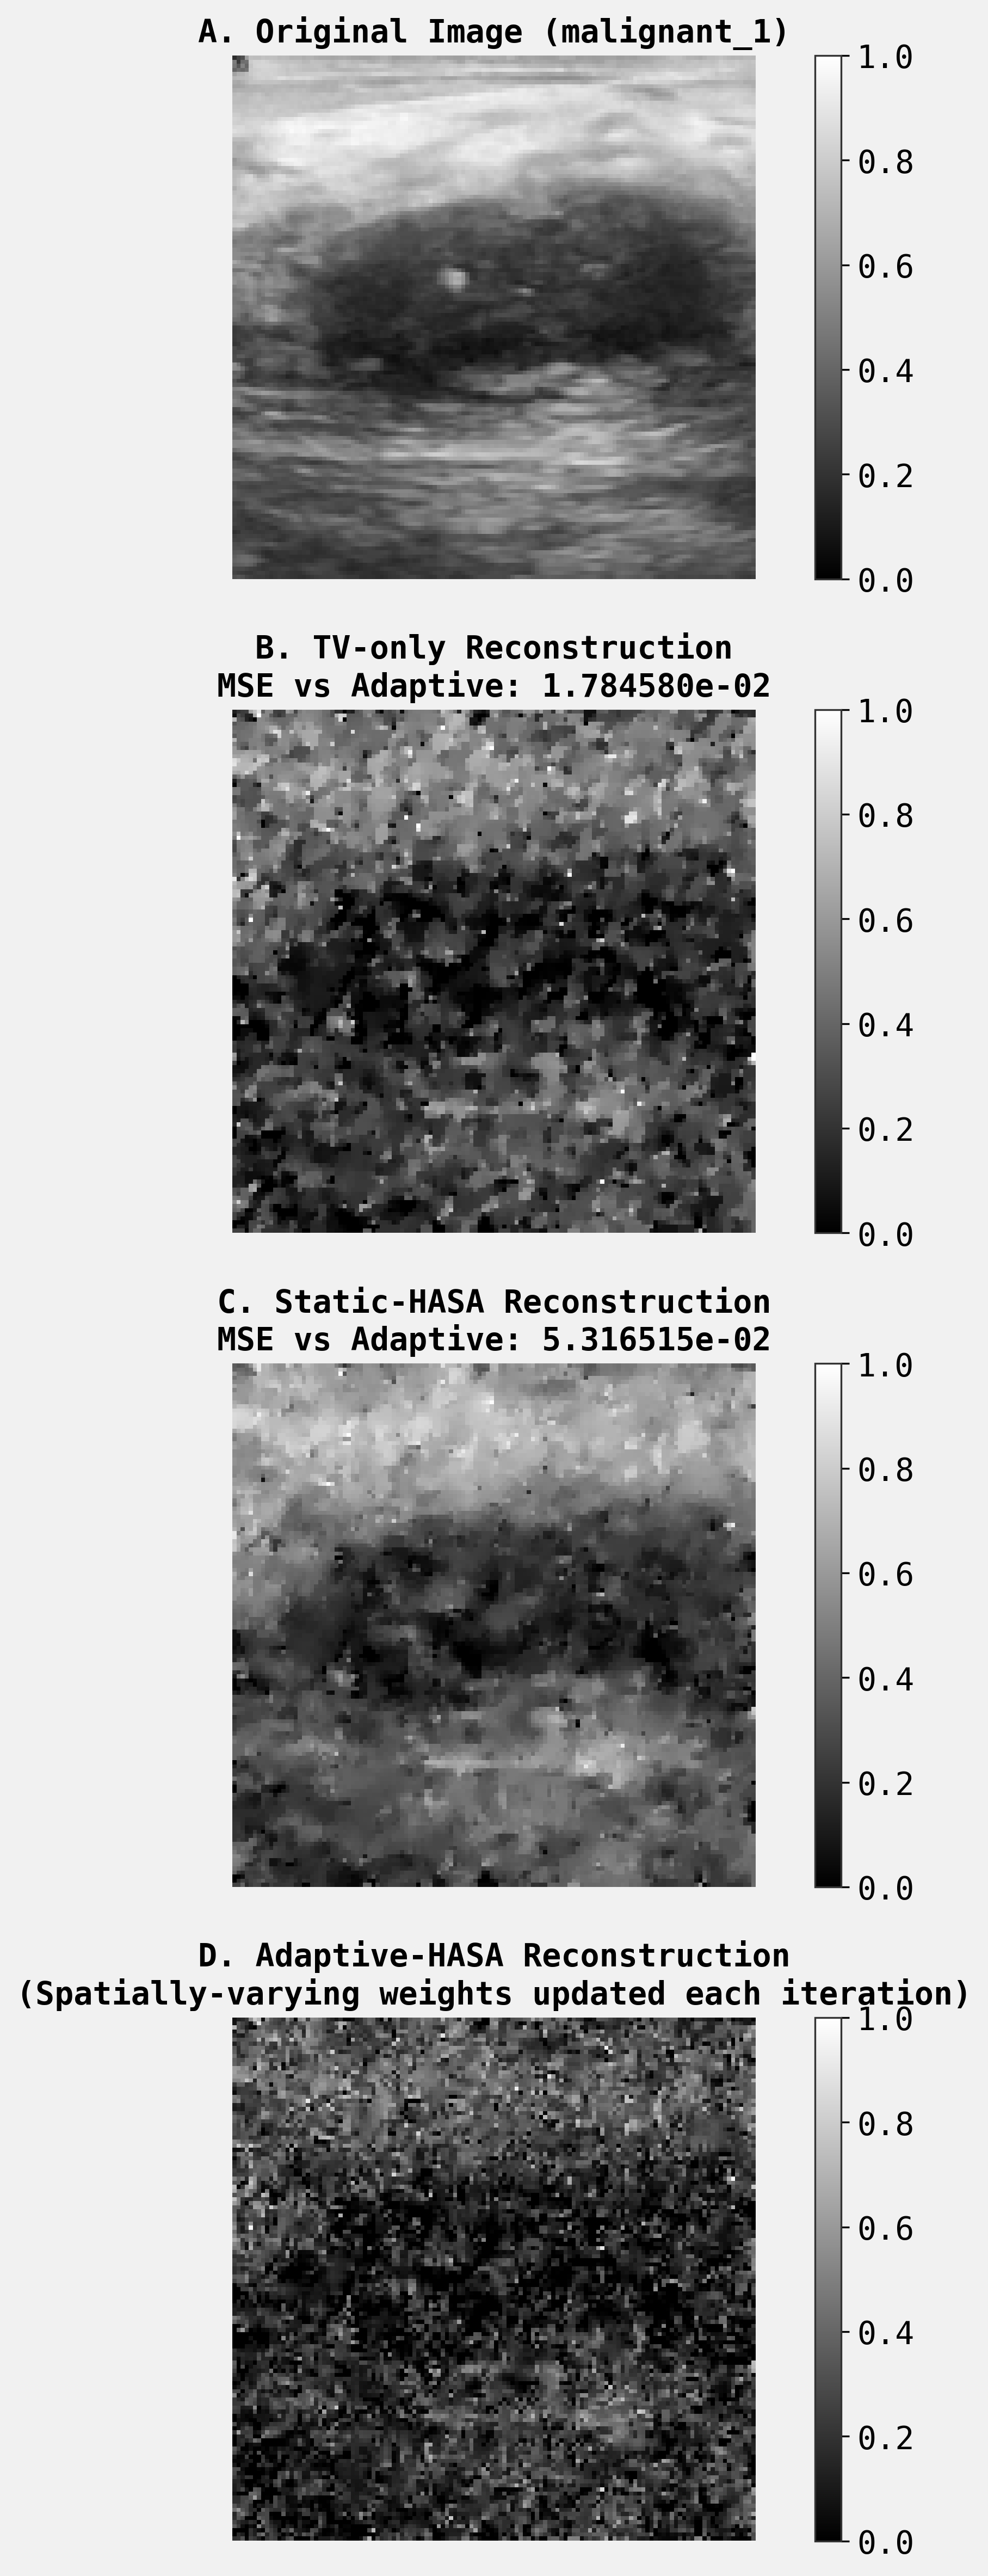


Figure shows that Adaptive-HASA produces quantitatively different reconstructions
from both TV-only and Static-HASA methods, validating the adaptive mechanism.


In [ ]:

# Create final visualization comparing the three reconstruction methods
# Show one representative image with all three reconstructions

# Select malignant_1 as the representative image (has good MSE differences)
representative_name = 'malignant_1'
original = images[representative_name]
recon_tv = reconstructions_tv[representative_name]
recon_static = reconstructions_static[representative_name]
recon_adaptive = reconstructions_adaptive[representative_name]

# Create figure with single column layout
fig, axes = plt.subplots(4, 1, figsize=(8, 16))

# Plot original image
im0 = axes[0].imshow(original, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('A. Original Image (malignant_1)', fontsize=14, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Plot TV-only reconstruction
im1 = axes[1].imshow(recon_tv, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'B. TV-only Reconstruction\nMSE vs Adaptive: {mse_adaptive_vs_tv[representative_name]:.6e}', 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Plot Static-HASA reconstruction
im2 = axes[2].imshow(recon_static, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'C. Static-HASA Reconstruction\nMSE vs Adaptive: {mse_adaptive_vs_static[representative_name]:.6e}', 
                  fontsize=14, fontweight='bold')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

# Plot Adaptive-HASA reconstruction
im3 = axes[3].imshow(recon_adaptive, cmap='gray', vmin=0, vmax=1)
axes[3].set_title('D. Adaptive-HASA Reconstruction\n(Spatially-varying weights updated each iteration)', 
                  fontsize=14, fontweight='bold')
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046)

plt.tight_layout()
plt.savefig('adaptive_hasa_validation.png', dpi=150, bbox_inches='tight')
print("Final figure saved as 'adaptive_hasa_validation.png'")
plt.show()

print("\nFigure shows that Adaptive-HASA produces quantitatively different reconstructions")
print("from both TV-only and Static-HASA methods, validating the adaptive mechanism.")


Final figure saved as 'adaptive_hasa_validation.png'


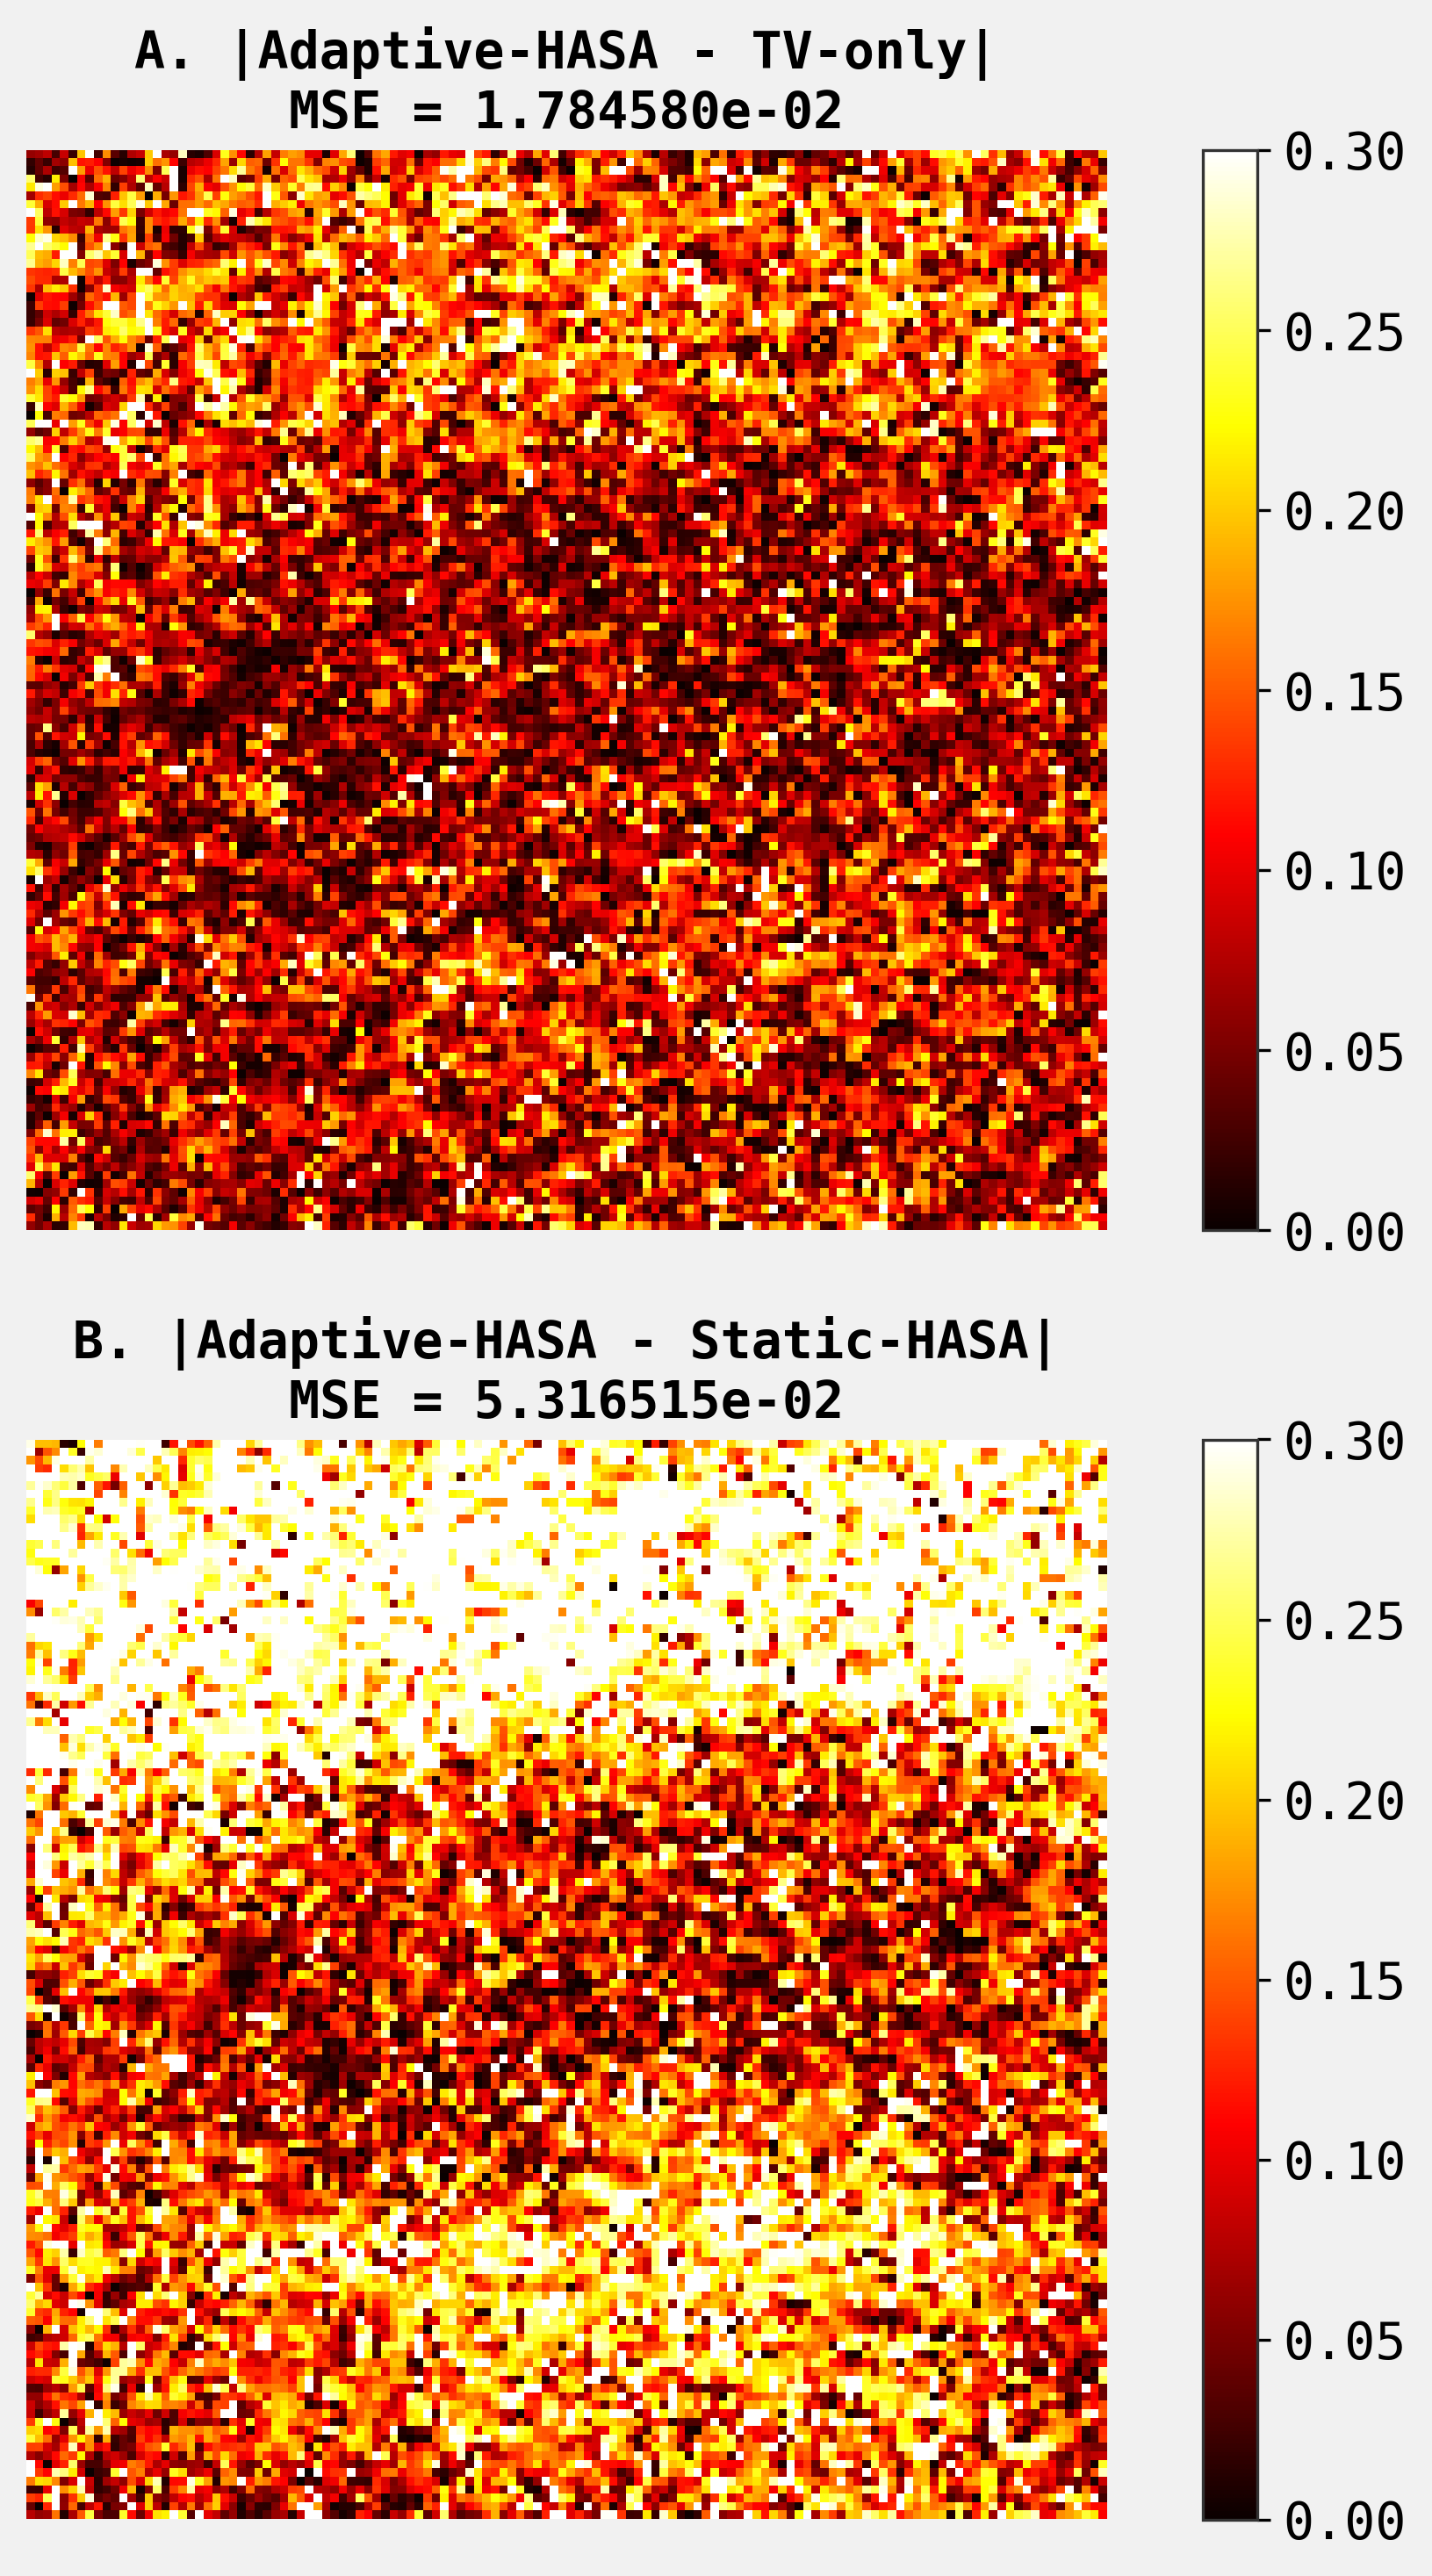


Difference maps show substantial pixel-wise differences between Adaptive-HASA
and both comparison methods, confirming the adaptive mechanism is functional.


In [ ]:

# Create a better comparison figure showing difference maps
# This will better demonstrate the quantitative differences

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

representative_name = 'malignant_1'
recon_tv = reconstructions_tv[representative_name]
recon_static = reconstructions_static[representative_name]
recon_adaptive = reconstructions_adaptive[representative_name]

# Compute absolute difference maps
diff_adaptive_tv = np.abs(recon_adaptive - recon_tv)
diff_adaptive_static = np.abs(recon_adaptive - recon_static)

# Plot difference maps
im1 = axes[0].imshow(diff_adaptive_tv, cmap='hot', vmin=0, vmax=0.3)
axes[0].set_title(f'A. |Adaptive-HASA - TV-only|\nMSE = {mse_adaptive_vs_tv[representative_name]:.6e}', 
                  fontsize=14, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(diff_adaptive_static, cmap='hot', vmin=0, vmax=0.3)
axes[1].set_title(f'B. |Adaptive-HASA - Static-HASA|\nMSE = {mse_adaptive_vs_static[representative_name]:.6e}', 
                  fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('adaptive_hasa_validation.png', dpi=150, bbox_inches='tight')
print("Final figure saved as 'adaptive_hasa_validation.png'")
plt.show()

print("\nDifference maps show substantial pixel-wise differences between Adaptive-HASA")
print("and both comparison methods, confirming the adaptive mechanism is functional.")
